#### Decodificando la Ley: Clasificación Inteligente y Búsqueda Semántica de Jurisprudencia Argentina

##### TP1 — Análisis y visualización de datos

Importamos las librerías y definimos la configuración base.

El dataset completo se descarga con el notebook `descarga-lectura-dataset.ipynb` de la raíz del repositorio.

In [1]:
import json
import os

import matplotlib.pyplot as plt
import pandas as pd

# Rutas relativas al notebook: os.path.join arma el separador correcto en Windows y Unix
DATASET_PATH = os.path.join("..", "datos", "full-dataset")
DATASET_FILE = os.path.join(DATASET_PATH, "dataset.jsonl")

# Semilla fija: cualquier muestreo aleatorio da el mismo resultado en cada corrida
RANDOM_SEED = 42

# Un solo color para todos los gráficos: cada marca es la misma magnitud medida sobre
# categorías distintas, no series distintas. Colorear por categoría no agregaría información.
COLOR_DATO = "#4C78A8"

# max_columns=None desactiva el "..." que pandas mete cuando hay muchas columnas
pd.set_option("display.max_columns", None)
# max_colwidth limita el ancho de cada celda: los fallos son textos largos y sin esto la tabla es ilegible
pd.set_option("display.max_colwidth", 120)

##### 1. Lectura del dataset completo

El archivo `dataset.jsonl` pesa ~2.5 GB en disco. `pd.read_json` construye el `DataFrame` entero en
memoria con copias intermedias, así que el pico de RAM es varias veces el tamaño final: en un equipo
con poca memoria libre el sistema empieza a paginar a disco y la celda pasa de tardar minutos a
tardar media hora.

Las secciones 2 a 4 necesitan las 71 columnas — analizar los nulos de todas las variables es
justamente su objetivo. La **sección 5 no**: usa 4 columnas y se carga por su cuenta en ~1 minuto,
así que se puede correr sin ejecutar esta celda.

Si el equipo no tiene RAM suficiente para las secciones 2 a 4, usar `datos/dataset_sample.jsonl.gz`
(muestra del 1%) o leer por chunks con `pd.read_json(..., lines=True, chunksize=...)`.

In [2]:
# lines=True lee JSON Lines: un objeto JSON por línea, no un único array
# El archivo pesa ~2.5 GB, así que esta celda tarda varios minutos y consume bastante RAM
df = pd.read_json(DATASET_FILE, lines=True)

# shape devuelve (filas, columnas); el formato :, agrega separador de miles
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Filas: 874,845
Columnas: 71


##### 2. 10 filas aleatorias

Fijamos `random_state` para que la muestra sea reproducible entre ejecuciones.

In [3]:
# random_state fija la semilla del muestreo para que estas 10 filas sean siempre las mismas
df.sample(10, random_state=RANDOM_SEED)

,numero-sumario,materia,sumario,descriptores,referencias-normativas,texto,fuente,analista,responsable,fecha,tipo-tribunal,instancia,jurisdiccion,provincia,caratula,fecha-alta,fecha-mod,uid-alta,uid-mod,timestamp,timestamp-m,timestamp-alta,id-infojus,fecha-umod,titulo,guid,numero-fallo,tribunal,pais,tipo-fallo,localidad,magistrados,actor,demandado,sobre,sumarios-relacionados,texto-doc,sala,numero-interno,tribunal-origen,publicacion,texto-completo,numero-camara,citas,jurisprudencia-vinculada,sintesis,hechos,identificacion-plenario,doctrina-relacionada,referencias-juris,control-constitucional,disidencia,esq-clasificacion,seq,archivo,tipo-norma,org_emisor,fecha_alta,ppublic_nov,d_link,fecha_umod,status,titulo_noticia,destacada,fecha_newsletter,suplemento_bo,subtipo,url_portal,nro_orden,fecha_destacada,sigla_emisor
613210,NaN,NaN,NaN,"{'descriptor': [{'elegido': {'termino': 'Término elegido para describir al caso'}, 'preferido': {'termino': 'Término...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN,123456789-0abc-defg9415-000ssoiramus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
195840,C0005865,CIVIL,[[p]]LOCACION DE INMUEBLES-CONVENIO DE DESOCUPACION:REQUISITOS[[/p]],"{'descriptor': [{'elegido': {'termino': 'locación de inmuebles'}, 'preferido': {'termino': 'Obligaciones y contratos...","{'referencia-normativa': [{'cr': None, 'id': 'REFERENCIAS_NORMATIVAS_0', 'ref': 'LEY C 021342 0000 00 00 0047 000 00...",[[p]]Si bien el art. 47 de la ley 21.342 establece que la homologación de un convenio de desocupación se dictar...,OFICIAL,NaN,NaN,1990-03-26,CI,C,"{'codigo': 'NACIONAL', 'descripcion': 'Nacional', 'capital': 'Nacional', 'id-pais': 11}",Ciudad Autónoma de Buenos Aires,"OLIVIERI, N. c/ BENITEZ, H. s/ HOMOLOGACION",1995-05-02,2013-05-20,SAUID,ABM,2013-05-20 15:26:51,2013-05-20 15:26:51,NaT,SUC0005865,NaN,"Locación de inmuebles, convenio de desocupación",123456789-0abc-defg5685-000csoiramus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F,R000061718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98445,B0035373,CIVIL - COMERCIAL,[[p]]RECURSO EXTRAORDINARIO;SENTENCIA RECURRIBLE:ACTUALIZACION MONETARIA[[/p]],"{'descriptor': [{'elegido': {'termino': 'recurso extraordinario'}, 'preferido': {'termino': 'Derecho procesal/recurs...","{'referencia-normativa': {'cr': None, 'id': 'REFERENCIAS_NORMATIVAS_0', 'ref': 'CPC B 007425 1968 09 19 0278 000 027...","[[p]]Es recurrible por vía extraordinaria (art. 278, CPC) la resolución recaída en ejecución de sentencia, cu...",OFICIAL,NaN,NaN,1992-04-28|1991-03-19|1991-08-20|1993-03-30,CS CS CS CS,S S S,"{'codigo': 'LOCAL', 'descripcion': 'Local', 'capital': 'Local', 'id-pais': 11}",Buenos Aires,"Campana, Francisco D. c/ De Benedittis, Eduardo s/ Daños y perjuicios. Recurso de queja Finansur SACF c/ Bohoslavsky...",1996-12-13,2014-06-05,SAUID,SASAIJ,2014-06-05 19:48:10,2014-06-05 19:48:10,NaT,SUB0035373,NaN,"Recurso extraordinario, resoluciones recurribles, actualización monetaria",123456789-0abc-defg3735-300bsoiramus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ac49842 Ac46663 Ac48638 Ac52501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
807045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Belloro, Mariana",2021-06-09,CS,S,"{'codigo': 'LOCAL', 'descripcion': 'Local', 'capital': 'Local', 'id-pais': 11}",Ciudad Autónoma de Buenos Aires,NaN,2022-01-11,2022-01-11,ABM,ABM,2022-01-11 15:09:14,2022-01-11 15:09:14,2022-01-11 14:19:06,FA21380107,NaN,NaN,123456789-701-0831-2ots-eupmocsollaf,21380107.0,TRIBUNAL SUPERIOR DE JUSTICIA DE LA CIUDAD DE BUENOS AIRES,ARGENTINA,SENTENCIA,CIUDAD DE BUENOS AIRES,Weinberg-Ruiz-De Langhe-Otamendi-Lozano,"Incidente de incompetencia en autos NN, NN sobre 153

##### 3. Listado de columnas

Además del nombre, miramos el tipo inferido por pandas: es el primer indicio de qué variables
son categóricas, cuáles son texto libre y cuáles son estructuras anidadas (listas o diccionarios).

In [4]:
# start=1 numera desde 1 en lugar de 0, solo para que el listado se lea más cómodo
for i, columna in enumerate(df.columns, start=1):
    # :>2 alinea el número a la derecha en 2 caracteres; dtype es el tipo que pandas infirió
    print(f"{i:>2}. {columna} ({df[columna].dtype})")

 1. numero-sumario (object)
 2. materia (str)
 3. sumario (str)
 4. descriptores (object)
 5. referencias-normativas (object)
 6. texto (str)
 7. fuente (str)
 8. analista (str)
 9. responsable (str)
10. fecha (object)
11. tipo-tribunal (str)
12. instancia (str)
13. jurisdiccion (object)
14. provincia (str)
15. caratula (str)
16. fecha-alta (str)
17. fecha-mod (str)
18. uid-alta (str)
19. uid-mod (str)
20. timestamp (datetime64[us])
21. timestamp-m (datetime64[us])
22. timestamp-alta (datetime64[us])
23. id-infojus (str)
24. fecha-umod (float64)
25. titulo (str)
26. guid (str)
27. numero-fallo (float64)
28. tribunal (str)
29. pais (str)
30. tipo-fallo (str)
31. localidad (str)
32. magistrados (object)
33. actor (object)
34. demandado (object)
35. sobre (object)
36. sumarios-relacionados (object)
37. texto-doc (object)
38. sala (object)
39. numero-interno (object)
40. tribunal-origen (object)
41. publicacion (object)
42. texto-completo (object)
43. numero-camara (object)
44. citas (obje

In [5]:
# verbose=True fuerza el listado completo de columnas (pandas lo colapsa cuando son muchas)
# show_counts=True garantiza la columna "Non-Null Count", que se omite en DataFrames grandes
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 874845 entries, 0 to 874844
Data columns (total 71 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   numero-sumario            483305 non-null  object        
 1   materia                   483305 non-null  str           
 2   sumario                   483305 non-null  str           
 3   descriptores              589273 non-null  object        
 4   referencias-normativas    237528 non-null  object        
 5   texto                     483295 non-null  str           
 6   fuente                    485286 non-null  str           
 7   analista                  112108 non-null  str           
 8   responsable               162212 non-null  str           
 9   fecha                     769745 non-null  object        
 10  tipo-tribunal             767118 non-null  str           
 11  instancia                 766558 non-null  str           
 12  jurisdiccion 

##### 4. Nulos por variable

`isna()` cuenta `None` / `NaN`, pero **no** cuenta strings vacíos ni listas vacías, que en este dataset
también representan ausencia de dato. Por eso medimos ambas cosas: nulos reales y "vacíos".

In [6]:
# Total de registros: lo usamos como denominador para los porcentajes
total_filas = len(df)

# Armamos una tabla resumen donde cada fila es una variable del dataset
nulos = pd.DataFrame(
    {
        # dtype como string para que entre prolijo en la tabla
        "dtype": df.dtypes.astype(str),
        # isna() marca True en los faltantes; sum() los cuenta por columna
        "nulos": df.isna().sum(),
        # notna() es el complemento: cuántos valores presentes tiene cada variable
        "no_nulos": df.notna().sum(),
    }
)
# Porcentaje de faltantes: más comparable entre variables que el conteo crudo
nulos["pct_nulos"] = (nulos["nulos"] / total_filas * 100).round(2)

# option_context levanta el límite de filas solo para este display: evita truncar las variables
# sin dejar el estado global del notebook modificado para el resto de las celdas
with pd.option_context("display.max_rows", None):
    # Ordenamos de mayor a menor para ver primero las variables más incompletas
    display(nulos.sort_values("nulos", ascending=False))

,dtype,nulos,no_nulos,pct_nulos
control-constitucional,str,874844,1,100.00
referencias-juris,object,874844,1,100.00
disidencia,str,874844,1,100.00
doctrina-relacionada,str,874844,1,100.00
esq-clasificacion,str,874844,1,100.00
sigla_emisor,str,874843,2,100.00
url_portal,str,874839,6,100.00
fecha_destacada,str,874835,10,100.00
nro_orden,float64,874835,10,100.00
fecha_newsletter,str,874700,145,99.98


In [7]:
def es_vacio(valor):
    """True si el valor es nulo, un string en blanco o una colección vacía."""
    # Listas y diccionarios vacíos: pd.isna() no los detecta, hay que medir su longitud
    if isinstance(valor, (list, tuple, dict, set)):
        return len(valor) == 0
    # Strings con solo espacios cuentan como ausencia de dato
    if isinstance(valor, str):
        return valor.strip() == ""
    # Para el resto alcanza con el chequeo estándar de pandas
    return pd.isna(valor)


# map() aplica la función celda por celda: es la operación más costosa del notebook.
# Guardamos la máscara booleana completa para reutilizarla y no recalcularla más abajo.
mask_vacios = df.map(es_vacio)

# sum() sobre la máscara cuenta los True por columna
vacios = mask_vacios.sum()

# Comparamos ambas mediciones: la diferencia son los "vacíos" que isna() no ve
faltantes = pd.DataFrame(
    {
        "nulos": nulos["nulos"],
        "nulos_o_vacios": vacios,
    }
)
faltantes["pct_nulos_o_vacios"] = (faltantes["nulos_o_vacios"] / total_filas * 100).round(2)

# Misma tabla por variable: mostramos todas las filas sin truncar
with pd.option_context("display.max_rows", None):
    display(faltantes.sort_values("nulos_o_vacios", ascending=False))

,nulos,nulos_o_vacios,pct_nulos_o_vacios
control-constitucional,874844,874844,100.00
referencias-juris,874844,874844,100.00
disidencia,874844,874844,100.00
doctrina-relacionada,874844,874844,100.00
esq-clasificacion,874844,874844,100.00
sigla_emisor,874843,874843,100.00
url_portal,874839,874839,100.00
fecha_destacada,874835,874835,100.00
nro_orden,874835,874835,100.00
fecha_newsletter,874700,874700,99.98


Y una mirada por fila: cuántas variables le faltan a cada registro.

In [8]:
# axis=1 suma a lo ancho: cuántos campos le faltan a CADA registro.
# Reutilizamos mask_vacios (misma vara que la celda anterior): cuenta nulos, strings
# en blanco y colecciones vacías. Con df.isna() un campo "" o [] contaría como presente.
faltantes_por_fila = mask_vacios.sum(axis=1)

# Registros completos: los más útiles para modelar sin imputar nada
filas_completas = (faltantes_por_fila == 0).sum()
print(f"Filas sin ningún faltante: {filas_completas:,} ({filas_completas / total_filas * 100:.2f}%)")
print(f"Total de columnas: {df.shape[1]}")
print("\nDistribución de faltantes por fila:")

# value_counts cuenta cuántas filas tienen N faltantes; sort_index las ordena por N ascendente
conteo_faltantes = faltantes_por_fila.value_counts().sort_index()

distribucion_faltantes = pd.DataFrame(
    {
        "filas": conteo_faltantes,
        # El conteo crudo no dice nada solo: 105.096 filas recién significan algo al saber
        # que son el 12% del dataset. El porcentaje es lo que hace comparable cada nivel.
        "pct": (conteo_faltantes / total_filas * 100).round(2),
    }
)
# cumsum sobre el porcentaje sin redondear: muestra dónde se acumula la masa de la distribución
distribucion_faltantes["pct_acum"] = (conteo_faltantes.cumsum() / total_filas * 100).round(2)
distribucion_faltantes.index.name = "faltantes"

# La distribución puede tener tantas categorías como columnas, así que la mostramos completa
with pd.option_context("display.max_rows", None):
    display(distribucion_faltantes)

Filas sin ningún faltante: 0 (0.00%)
Total de columnas: 71

Distribución de faltantes por fila:


,filas,pct,pct_acum
faltantes,,,
39,3,0.00,0.00
40,64,0.01,0.01
41,523,0.06,0.07
42,1215,0.14,0.21
43,8339,0.95,1.16
44,22237,2.54,3.70
45,60813,6.95,10.65
46,98880,11.30,21.96
47,196408,22.45,44.41


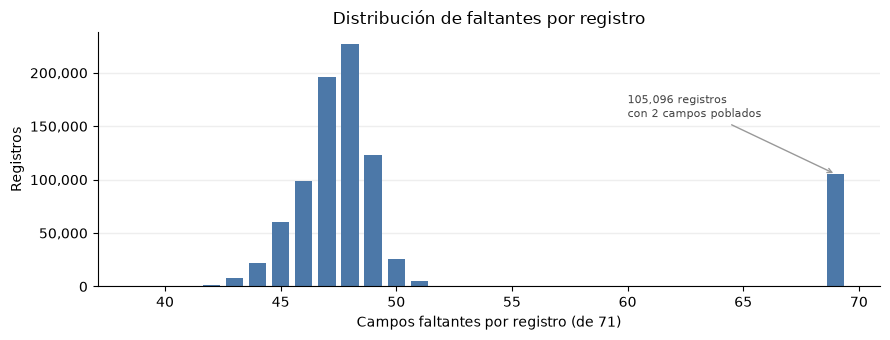

In [9]:
# El pico aislado: el nivel de faltantes más alto de la distribución
pico_aislado = conteo_faltantes.index.max()

fig, ax = plt.subplots(figsize=(9, 3.5))

# Barras sobre eje NUMÉRICO, no categórico. Es la decisión que hace al gráfico: en un eje
# categórico el 59 y el 69 quedarían pegados y el hueco entre los dos grupos —que es el
# hallazgo— desaparecería. Sobre el eje numérico el vacío se ve como lo que es.
ax.bar(distribucion_faltantes.index, distribucion_faltantes["filas"], color=COLOR_DATO, width=0.75)

# Escala lineal a propósito: el eje log aplanaría la diferencia entre los dos modos,
# que es justamente la magnitud que hay que ver.
ax.set_xlabel("Campos faltantes por registro (de 71)")
ax.set_ylabel("Registros")
ax.set_title("Distribución de faltantes por registro")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")

# Etiqueta directa sobre el grupo aislado: es el único que necesita explicación
ax.annotate(
    f"{conteo_faltantes.loc[pico_aislado]:,} registros\ncon {df.shape[1] - pico_aislado} campos poblados",
    xy=(pico_aislado, conteo_faltantes.loc[pico_aislado]),
    xytext=(pico_aislado - 9, conteo_faltantes.max() * 0.7),
    fontsize=8,
    color="#444444",
    arrowprops=dict(arrowstyle="->", color="#999999", linewidth=1),
)

# Ejes recesivos: el dato son las barras, no el marco
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#EEEEEE", linewidth=1)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

La distribución es **bimodal** y ese es el hallazgo de la sección. El 87% de los registros cae
entre 44 y 51 faltantes: son documentos de la misma forma, con 20 a 27 campos poblados. Pero hay
un segundo grupo, separado del resto y clavado en un único valor, con casi todos los campos vacíos.

Que 105.096 registros compartan **exactamente** la misma cantidad de faltantes no es degradación
gradual: es un tipo de registro distinto conviviendo en el mismo archivo. Antes de seguir hay que
ver qué campos sobreviven ahí, porque de eso depende si el universo de trabajo son 874.845
documentos o 769.749.

In [10]:
# El grupo degenerado es el del máximo de faltantes: los registros más vacíos del dataset
max_faltantes = faltantes_por_fila.max()
es_degenerado = faltantes_por_fila == max_faltantes

# mean() sobre una máscara booleana da directamente la proporción de True
print(f"Registros con {max_faltantes} faltantes: {es_degenerado.sum():,} ({es_degenerado.mean() * 100:.2f}%)")
print(f"Campos poblados por registro: {df.shape[1] - max_faltantes}")

# ~mask_vacios invierte la máscara: True donde SÍ hay dato. Sumando por columna sobre el
# subconjunto sabemos qué campos sobreviven. Si todos los conteos son iguales al tamaño del
# bloque, el grupo es homogéneo: los mismos campos en todos los registros, no una mezcla.
presentes = (~mask_vacios.loc[es_degenerado]).sum()
columnas_presentes = presentes[presentes > 0].sort_values(ascending=False)

print("\nCampos con dato en ese bloque:")
display(columnas_presentes)

# Las primeras filas del bloque, con las columnas que efectivamente traen algo:
# ver los valores reales es lo que dice si son documentos recuperables o cáscaras vacías
print("Muestra del bloque:")
display(df.loc[es_degenerado, columnas_presentes.index].head(10))


Registros con 69 faltantes: 105,096 (12.01%)
Campos poblados por registro: 2

Campos con dato en ese bloque:


descriptores    105096
guid            105096
dtype: int64

Muestra del bloque:


,descriptores,guid
4,"{'descriptor': [{'elegido': {'termino': 'Término elegido para describir al caso'}, 'preferido': {'termino': 'Término...",123456789-0abc-defg3036-300nsoiramus
11,"{'descriptor': [{'elegido': {'termino': 'Término elegido para describir al caso'}, 'preferido': {'termino': 'Término...",123456789-0abc-defg4236-300nsoiramus
13,"{'descriptor': [{'elegido': {'termino': 'Término elegido para describir al caso'}, 'preferido': {'termino': 'Término...",123456789-0abc-defg6136-300nsoiramus
73,"{'descriptor': [{'elegido': {'termino': 'Término elegido para describir al caso'}, 'preferido': {'termino': 'Término...",123456789-0abc-defg7936-300nsoiramus
114,"{'descriptor': [{'elegido': {'termino': 'Término elegido para describir al caso'}, 'preferido': {'termino': 'Término...",123456789-0abc-defg0146-300nsoiramus
116,"{'descriptor': [{'elegido': {'termino': 'Término elegido para describir al caso'}, 'preferido': {'termino': 'Término...",123456789-0abc-defg9136-300nsoiramus
169,"{'descriptor': [{'elegido': {'termino': 'Término elegido para describir al caso'}, 'preferido': {'termino': 'Término...",123456789-0abc-defg8336-300nsoiramus
221,"{'descriptor': [{'elegido': {'termino': 'Término elegido para describir al caso'}, 'preferido': {'termino': 'Término...",123456789-0abc-defg5726-300nsoiramus
280,"{'descriptor': [{'elegido': {'termino': 'Término elegido para describir al caso'}, 'preferido': {'termino': 'Término...",123456789-0abc-defg4536-300nsoiramus
341,"{'descriptor': [{'elegido': {'termino': 'Término elegido para describir al caso'}, 'preferido': {'termino': 'Término...",123456789-0abc-defg6605-800asoiramus


Las tablas de arriba dejan una pregunta abierta: varias variables comparten **exactamente** el mismo
conteo de faltantes (105.363 en cuatro de ellas, 161 en trece, 1 en cinco). Eso no es casualidad, y
una tabla ordenada no lo puede mostrar: son grupos de columnas que **se pueblan juntas o no se
pueblan nunca**, porque pertenecen a tipos de documento distintos.

El mapa de presencia lo hace visible de una. Cada fila es un registro y cada columna una variable;
ordenamos las columnas por completitud y las filas por su patrón de faltantes, y lo que aparecen son
bloques rectangulares. Cada bloque es un tipo de documento: **las 71 columnas no son 71 variables de
un mismo objeto, son la unión de varios esquemas conviviendo en el mismo archivo**. Es la conclusión
que gobierna todo lo que viene después — no tiene sentido imputar una variable que directamente no
existe para ese tipo de registro.

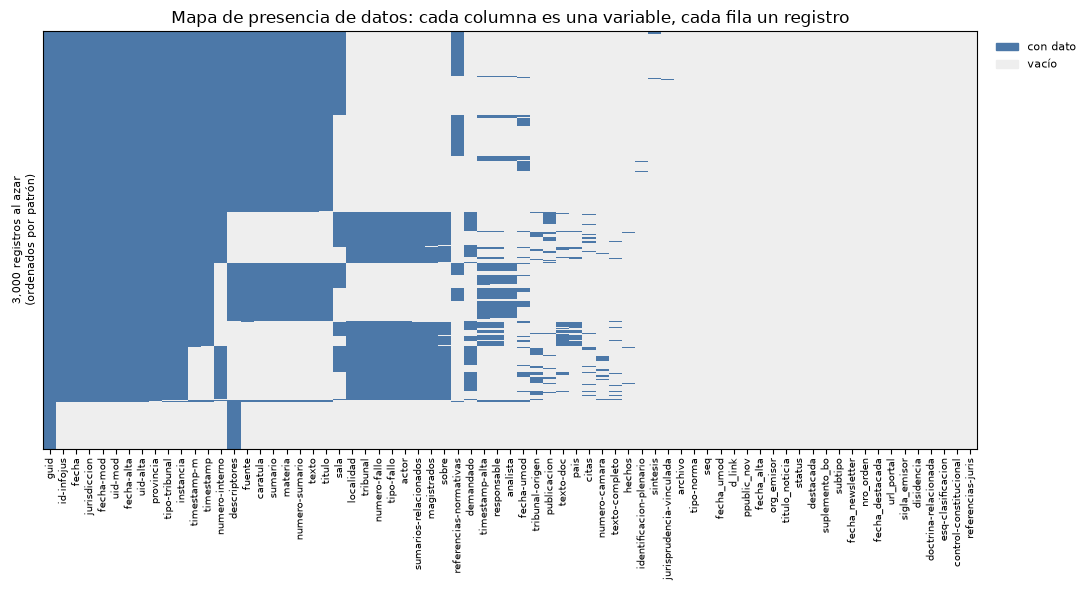

In [11]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Dibujar las 874.845 filas no aportaría nada: cada una ocuparía una fracción de píxel.
# Con unos miles de registros al azar el patrón ya se lee y la figura se arma en segundos.
MUESTRA_MATRIZ = 3000

# Columnas ordenadas de la más completa a la más vacía: deja juntas las que se pueblan a la vez
orden_columnas = list(mask_vacios.sum().sort_values().index)

# random_state fija la muestra; el sort_values por las 71 columnas es un orden lexicográfico
# sobre el patrón de faltantes: agrupa los registros que tienen la misma forma, y eso es lo
# que convierte una nube de puntos sueltos en bloques legibles.
muestra = mask_vacios.sample(MUESTRA_MATRIZ, random_state=RANDOM_SEED)[orden_columnas].sort_values(
    by=orden_columnas
)

# ~ invierte la máscara: 1 donde SÍ hay dato. astype(int) porque imshow espera números.
presencia = (~muestra).astype(int).values

fig, ax = plt.subplots(figsize=(11, 6))

# Dos estados, dos colores: el dato presente en el color del notebook, el vacío en gris
# claro. interpolation="nearest" evita que matplotlib difumine los bordes entre bloques.
ax.imshow(presencia, aspect="auto", interpolation="nearest", cmap=ListedColormap(["#EEEEEE", COLOR_DATO]))

ax.set_xticks(range(len(orden_columnas)), orden_columnas, rotation=90, fontsize=7)
# Las filas no tienen identidad propia (son una muestra ordenada), así que el eje y no lleva marcas
ax.set_yticks([])
ax.set_ylabel(f"{MUESTRA_MATRIZ:,} registros al azar\n(ordenados por patrón)", fontsize=8)
ax.set_title("Mapa de presencia de datos: cada columna es una variable, cada fila un registro")

# Con dos estados el color solo no alcanza para identificarlos: la referencia es obligatoria
ax.legend(
    handles=[Patch(color=COLOR_DATO, label="con dato"), Patch(color="#EEEEEE", label="vacío")],
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    frameon=False,
    fontsize=8,
)

plt.tight_layout()
plt.show()

##### 5. Desbalance de clases

Miramos las cuatro variables candidatas a etiqueta del clasificador: `materia`, `descriptores`,
`tipo-tribunal` y `jurisdiccion`. Cada una tiene una forma distinta en el JSON y ninguna se puede
contar con un `value_counts()` directo:

| variable | forma en el dataset | tipo de problema |
|---|---|---|
| `materia` | string, a veces con varias materias unidas por guion | multiclase (una etiqueta por sumario) |
| `descriptores` | dict anidado con una lista de términos | multietiqueta (varios términos por sumario) |
| `tipo-tribunal` | string con código corto (`CS`, `CC`, `LB`, ...) | multiclase |
| `jurisdiccion` | dict con `codigo`, `descripcion`, `capital`, `id-pais` | multiclase |

De cada una nos interesan tres números, más informativos que el gráfico: el **ratio entre la clase
mayoritaria y la minoritaria**, **cuántas clases tienen menos de 50 ejemplos** (no se pueden aprender
ni validar con partición estratificada) y la **cobertura acumulada** del top-N.

Esta sección carga su propio `DataFrame` con las 4 columnas que necesita, en lugar de reusar el `df`
de 71 columnas de la sección 1. No es una optimización prematura: son ~1 minuto y 0,3 GB de RAM
contra los varios GB del `df` completo, y permite trabajar la sección de forma independiente.

In [12]:
# Las únicas columnas que necesita esta sección
COLUMNAS_CLASES = ["materia", "descriptores", "tipo-tribunal", "jurisdiccion"]


def leer_columnas(ruta, columnas):
    """Lee un JSON Lines quedándose solo con `columnas`.

    `pd.read_json` no tiene `usecols`: carga el archivo entero sí o sí. Parseando línea a
    línea con `json.loads` descartamos el resto de los campos ANTES de construir el
    DataFrame, que es donde está el ahorro de memoria.
    """
    registros = []
    with open(ruta, encoding="utf-8") as f:
        for linea in f:
            registro = json.loads(linea)
            # get() con default None: no todos los registros traen las 4 claves
            registros.append({c: registro.get(c) for c in columnas})
    return pd.DataFrame(registros)


df_clases = leer_columnas(DATASET_FILE, COLUMNAS_CLASES)

# Cantidad de registros: mismo universo que el df completo, sirve de control
total_registros = len(df_clases)
print(f"Filas: {total_registros:,}")
print(f"Columnas: {df_clases.shape[1]}")
# deep=True mide el tamaño real de los objetos de Python, no solo el de los punteros
print(f"RAM: {df_clases.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Filas: 874,845
Columnas: 4
RAM: 0.29 GB


In [13]:
# Umbral por debajo del cual una clase es inviable: con menos ejemplos no alcanza
# para partir en train/test estratificado y que queden casos en ambos lados.
MIN_EJEMPLOS_CLASE = 50


def resumen_desbalance(clases, nombre, top=25):
    """Tabla de frecuencias + métricas de desbalance para una serie ya desanidada.

    `clases` es una Series donde cada fila es UNA etiqueta. En variables multietiqueta
    hay más filas que registros, por eso informamos ambos totales.
    """
    conteo = clases.value_counts()
    total_etiquetas = len(clases)

    # Porcentaje sin redondear: es la base de todos los cálculos
    pct = conteo / total_etiquetas * 100

    resumen = pd.DataFrame({"n": conteo})
    # Porcentaje sobre el total de etiquetas: comparable entre variables de distinto tamaño
    resumen["pct"] = pct.round(2)
    # El acumulado se calcula ANTES de redondear. Con miles de clases, sumar porcentajes ya
    # redondeados a 2 decimales pierde tanto en la cola que el acumulado nunca llega a 100.
    resumen["pct_acum"] = pct.cumsum().round(2)

    raras = (conteo < MIN_EJEMPLOS_CLASE).sum()

    print(f"--- {nombre} ---")
    print(f"Etiquetas totales: {total_etiquetas:,}")
    print(f"Clases distintas:  {len(conteo):,}")
    print(f"Clase mayoritaria: {conteo.index[0]} ({conteo.iloc[0]:,} | {resumen['pct'].iloc[0]}%)")
    # max/min es la medida directa de cuán torcida está la distribución.
    # Con colas de clases únicas el mínimo es 1 y el ratio equivale al conteo de la mayoritaria.
    print(f"Ratio mayoritaria/minoritaria: {conteo.max() / conteo.min():,.0f}x")
    print(f"Clases con menos de {MIN_EJEMPLOS_CLASE} ejemplos: {raras:,} ({raras / len(conteo) * 100:.1f}% de las clases)")

    # min() recorta cada N a la cantidad real de clases; sorted + dict.fromkeys deduplica
    # DESPUÉS del recorte y deja las líneas en orden creciente.
    for n in dict.fromkeys(sorted(min(n, len(conteo)) for n in (10, top))):
        print(f"Cobertura del top-{n}: {resumen['pct_acum'].iloc[n - 1]}%")

    return resumen


def mostrar_cabeza_y_cola(resumen, cabeza=40, cola=10):
    """Muestra las primeras y las últimas filas de una tabla de frecuencias.

    El resumen tiene tantas filas como clases distintas (miles en algunas variables), así que
    mostrarlo entero no se lee. Pero mostrar solo la cabeza esconde la cola larga, que es
    justamente donde vive el desbalance: por eso mostramos las dos puntas y decimos cuántas
    clases quedan en el medio, para que el recorte no se confunda con el total.
    """
    total = len(resumen)

    # Si la tabla entra completa no tiene sentido partirla en dos
    if total <= cabeza + cola:
        with pd.option_context("display.max_rows", None):
            display(resumen)
        return

    with pd.option_context("display.max_rows", cabeza):
        display(resumen.head(cabeza))
    print(f"... {total - cabeza - cola:,} clases intermedias sin mostrar (de {total:,} en total) ...")
    with pd.option_context("display.max_rows", cola):
        display(resumen.tail(cola))


def graficar_top(conteo, titulo, top=20):
    """Dot plot del top-N de clases, en escala logarítmica.

    Punto y no barra a propósito: el rango de estas variables abarca varios órdenes de
    magnitud y necesita eje logarítmico, pero una barra codifica LONGITUD DESDE CERO y la
    escala log no tiene cero — la barra de una clase con 171 casos se vería como un quinto
    de otra con 33.268, no como un 195-avo. El punto codifica posición, no longitud, así
    que sobre un eje log sigue diciendo la verdad.
    """
    datos = conteo.head(top).sort_values()
    posiciones = range(len(datos))

    fig, ax = plt.subplots(figsize=(9, max(4, len(datos) * 0.32)))

    # Línea guía tenue desde el borde del gráfico hasta el punto: ayuda a seguir la fila
    # sin competir visualmente con el dato.
    ax.hlines(posiciones, datos.min() * 0.85, datos.values, color="#D0D0D0", linewidth=1)
    ax.plot(datos.values, posiciones, "o", markersize=8, color=COLOR_DATO)

    ax.set_yticks(list(posiciones), datos.index.astype(str))
    ax.set_xscale("log")
    ax.set_xlabel("Cantidad de registros (escala log)")
    ax.set_title(titulo)

    # Etiqueta directa al lado de cada punto: evita leer el eje para cada valor
    for y, valor in zip(posiciones, datos.values):
        ax.text(valor * 1.12, y, f"{valor:,}", va="center", fontsize=8, color="#444444")

    # Ejes recesivos: el dato es el punto, no el marco
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0)
    # Grilla vertical suave por detrás, como referencia de magnitud
    ax.grid(axis="x", color="#EEEEEE", linewidth=1)
    ax.set_axisbelow(True)
    # Margen a ambos lados para que ni la guía ni la etiqueta directa se corten
    ax.set_xlim(datos.min() * 0.8, datos.max() * 2.2)

    plt.tight_layout()
    plt.show()

###### 5.1 `materia`

Es texto libre cargado por el analista, no un catálogo cerrado: aparecen combinaciones
(`CIVIL - COMERCIAL`, `PENAL-PROCESAL`) y el mismo valor escrito de varias formas
(`CIVIL-COMERCIAL` vs `CIVIL - COMERCIAL`). Contamos primero el valor crudo y después una
versión normalizada, para ver cuánto del "desbalance" es en realidad suciedad de carga.

In [14]:
# Valor crudo, tal como viene en el JSON. dropna() saca los 391.540 registros sin materia
# (son documentos que no son sumarios: la variable solo existe para una parte del dataset).
materia_cruda = df_clases["materia"].dropna()

resumen_materia_cruda = resumen_desbalance(materia_cruda, "materia (valor crudo)")

mostrar_cabeza_y_cola(resumen_materia_cruda)

--- materia (valor crudo) ---
Etiquetas totales: 483,305
Clases distintas:  2,636
Clase mayoritaria: PROCESAL (64,845 | 13.42%)
Ratio mayoritaria/minoritaria: 64,845x
Clases con menos de 50 ejemplos: 2,417 (91.7% de las clases)
Cobertura del top-10: 73.44%
Cobertura del top-25: 85.99%


,n,pct,pct_acum
materia,,,
PROCESAL,64845,13.42,13.42
PENAL,54694,11.32,24.73
LABORAL,45436,9.40,34.13
CIVIL,45232,9.36,43.49
CIVIL - COMERCIAL,39082,8.09,51.58
ADMINISTRATIVO,32322,6.69,58.27
CONSTITUCIONAL,24899,5.15,63.42
CIVIL-COMERCIAL,19792,4.10,67.51
COMERCIAL,19704,4.08,71.59


... 2,586 clases intermedias sin mostrar (de 2,636 en total) ...


,n,pct,pct_acum
materia,,,
POLITICO-LABORAL-SEGURIDAD SOCIAL,1,0.0,100.0
COMERCIAL-ADUANERO-PROCESAL-TRIBUTARIO,1,0.0,100.0
INTERNACIONAL PUBLICO-DERECHOS HUMANOS-PENAL,1,0.0,100.0
ADMINISTRATIVO-ECONOMIA-FINANZAS-PROCESAL,1,0.0,100.0
AERONAUTICO-PENAL-PROCESAL,1,0.0,100.0
ADUANERO-ECONOMIA-FINANZAS-PROCESAL-TRIBUTARIO,1,0.0,100.0
PROCESAL-LABORAL-SEGURIDAD SOCIAL-CIVIL,1,0.0,100.0
CIVIL-COMERCIAL-CONSTITUCIONAL-LABORAL,1,0.0,100.0
INTERNACIONAL PUBLICO-LABORAL-PROCESAL,1,0.0,100.0


**Criterio de normalización de `materia`**

Las 2.636 formas distintas de arriba no son 2.636 materias: son unas pocas ramas del derecho
escritas de muchas maneras. Y hay una pista que define todo el criterio: `CIVIL - COMERCIAL`
(39.082) convive con `COMERCIAL-CIVIL` (1.115), y `PROCESAL-PENAL` (7.559) con `PENAL-PROCESAL`
(8.926). **El orden se invierte.** Eso solo pasa cuando el campo guarda un conjunto, no un nombre
compuesto. A eso se suman cadenas como `ADUANERO-ECONOMIA-FINANZAS-PROCESAL-TRIBUTARIO`: nadie
bautiza una rama del derecho con cinco guiones.

Conclusión: `materia` es un campo **multivaluado** y el guion es un separador. Pero limpiar con
reglas de string no alcanza, porque el problema de fondo no es tipográfico sino taxonómico: hay que
saber cuáles son las ramas válidas. Por eso declaramos un **vocabulario controlado** de ramas del
derecho argentino y mapeamos cada fragmento contra él, en lugar de deducir la taxonomía a partir de
los separadores.

| paso | qué hace | ejemplo |
|---|---|---|
| 1. limpieza | `upper()`, `sin_acentos()`, colapsa espacios, pela el prefijo `DERECHO ` y la puntuación colgante | `Derecho Tributario` → `TRIBUTARIO`, `CIVIL:` → `CIVIL` |
| 2. separación | corta por `-`, `,`, `/`, `.`, `_`, `:`, `;` y la conjunción ` Y ` | `CONSTITUCIONAL. CIVIL. LABORAL` → 3 fragmentos |
| 3. canonización | mapea cada fragmento al vocabulario; lo que no matchea cae en `OTRAS` y queda auditado | `MEDIO AMBIENTE` → `AMBIENTAL` |
| 4. recomposición | colapsa `PROCESAL` + una sustantiva adjetivable en su subrama | `PENAL-PROCESAL` → `PROCESAL PENAL` |

**No separamos por espacio.** Hay ramas legítimas de dos palabras (`SEGURIDAD SOCIAL`,
`DERECHOS HUMANOS`, `RECURSOS NATURALES`) que quedarían hechas fragmentos sin sentido. Preferimos
arrastrar algo de ruido antes que inventar clases.

**Paso 4: por qué el derecho procesal necesita trato aparte.** Sin este paso, `PROCESAL PENAL`
(2.801 registros, escrito con espacio) queda como una clase propia mientras `PROCESAL-PENAL` /
`PENAL-PROCESAL` / `PROCESAL - PENAL` (~21.000, escritos con guion) se parten en dos etiquetas: el
mismo concepto en dos lugares distintos según cómo lo tipeó el analista. El derecho procesal es la
rama **adjetiva**, y sus subramas tienen autonomía reconocida porque cada una tiene su propio
cuerpo normativo: CPPN (Ley 23.984) y CPPF (Ley 27.063) para el procesal penal, CPCCN (Ley 17.454)
para el civil y comercial, Ley 18.345 para el procedimiento laboral, y amparo (Ley 16.986), habeas
corpus (Ley 23.098) y habeas data (Ley 25.326) para el procesal constitucional. Por eso `PROCESAL`
junto a **exactamente una** sustantiva adjetivable colapsa en la subrama correspondiente.

Con dos o más adjetivables no hay forma de saberlo: `CONSTITUCIONAL-PROCESAL-PENAL` (1.016) puede
leerse como procesal penal + constitucional o como procesal constitucional + penal. En ese caso
`PROCESAL` queda como género y no inventamos nada. La regla declara su propia ignorancia en vez de
tirar una moneda.

**Civil y comercial se mantienen separados**, y es una decisión consciente que va contra la letra
del derecho vigente: desde la Ley 26.994 (vigente 1/8/2015) rige un **Código Civil y Comercial de
la Nación** unificado, así que hoy son formalmente una sola rama. Los mantenemos aparte por dos
razones. Primero, el corpus cubre décadas anteriores a la unificación, cuando el Código Civil de
Vélez Sarsfield y el Código de Comercio eran cuerpos distintos y la distinción del catalogador
correspondía a una diferencia real. Segundo, el propio dataset las distingue con volumen: 45.232
`CIVIL` y 19.704 `COMERCIAL` puros contra 39.082 `CIVIL - COMERCIAL`. Fusionarlas destruiría esa
señal sin poder recuperarla después, mientras que separarlas permite unirlas más adelante si el
modelo lo pide. Consecuencia práctica: `CIVIL Y COMERCIAL` se parte en dos etiquetas, igual que
`CIVIL - COMERCIAL`.

Consecuencia importante para el modelado: la normalización **cambia el tipo de problema**. El valor
crudo es multiclase (una etiqueta por sumario); al partir las compuestas, un sumario pasa a tener
varias ramas y el problema se vuelve multietiqueta. Por eso el total de etiquetas de la tabla
siguiente es mayor que la cantidad de sumarios, y los porcentajes se leen sobre etiquetas, no sobre
registros.

In [ ]:
import re
import unicodedata


def sin_acentos(texto):
    """Deja la letra base y descarta la tilde: 'NAVEGACIÓN' -> 'NAVEGACION'."""
    # NFKD separa cada letra de su marca diacrítica; combining() identifica esas marcas
    return "".join(c for c in unicodedata.normalize("NFKD", texto) if not unicodedata.combining(c))


# Vocabulario controlado: ramas sustantivas del derecho argentino presentes en el corpus.
# CIVIL y COMERCIAL van separadas a propósito, pese al CCyCN unificado (ver criterio arriba).
RAMAS_SUSTANTIVAS = {
    "ADMINISTRATIVO", "ADUANERO", "AERONAUTICO", "AGRARIO", "AGUAS", "AMBIENTAL",
    "BANCARIO", "CIVIL", "COMERCIAL", "CONSTITUCIONAL", "CONTRAVENCIONAL", "CULTURA",
    "DERECHOS HUMANOS", "ECONOMIA", "EDUCACION", "ELECTORAL", "FINANZAS", "INFORMATICO",
    "INTERNACIONAL", "INTERNACIONAL PRIVADO", "INTERNACIONAL PUBLICO", "LABORAL",
    "MILITAR", "NAVEGACION", "PENAL", "POLITICO", "RECURSOS NATURALES", "SALUD PUBLICA",
    "SEGURIDAD SOCIAL", "TRIBUTARIO",
}

# Sustantivas con cuerpo procesal propio: habilitan una subrama adjetiva autónoma.
ADJETIVABLES = {
    "ADMINISTRATIVO", "CIVIL", "COMERCIAL", "CONSTITUCIONAL", "LABORAL", "PENAL", "TRIBUTARIO",
}

VOCABULARIO = RAMAS_SUSTANTIVAS | {"PROCESAL"} | {f"PROCESAL {r}" for r in ADJETIVABLES}

# Variantes de escritura que apuntan a la misma rama canónica.
ALIAS = {"MEDIO AMBIENTE": "AMBIENTAL"}

# Todo lo que los analistas usaron para separar materias. El espacio NO entra: hay ramas
# legítimas de dos palabras (SEGURIDAD SOCIAL, DERECHOS HUMANOS, RECURSOS NATURALES).
SEPARADORES = re.compile(r"[-,/._:;]|\sY\s")

# 'DERECHO TRIBUTARIO' y 'TRIBUTARIO' son la misma rama. No toca 'DERECHOS HUMANOS':
# exige un espacio inmediatamente después de DERECHO, y ahí hay una S.
PREFIJO_DERECHO = re.compile(r"^DERECHO\s+")


def desarmar_materia(valor):
    """Parte el valor crudo en términos limpios, sin juzgar todavía si son ramas válidas."""
    terminos = set()
    for fragmento in SEPARADORES.split(sin_acentos(valor).upper()):
        # \s+ colapsa espacios repetidos y strip() saca la puntuación que quedó colgando
        termino = PREFIJO_DERECHO.sub("", re.sub(r"\s+", " ", fragmento).strip(" .:;_-"))
        if termino:
            terminos.add(ALIAS.get(termino, termino))
    return terminos


def recomponer_procesales(ramas):
    """Colapsa PROCESAL + una sustantiva adjetivable en su subrama procesal.

    'PENAL-PROCESAL' y 'PROCESAL PENAL' son el mismo concepto tipeado distinto: ambos
    terminan en PROCESAL PENAL. Con dos o más adjetivables el original es ambiguo
    ('CONSTITUCIONAL-PROCESAL-PENAL'), así que dejamos PROCESAL como género.
    """
    if "PROCESAL" not in ramas:
        return ramas
    candidatas = ramas & ADJETIVABLES
    if len(candidatas) != 1:
        return ramas
    sustantiva = next(iter(candidatas))
    return (ramas - {"PROCESAL", sustantiva}) | {f"PROCESAL {sustantiva}"}


def normalizar_materia(valor):
    """Mapea el valor crudo al conjunto de ramas del derecho que le corresponden."""
    # Lo que no está en el vocabulario cae en OTRAS; fuera_de_vocabulario lo audita abajo
    ramas = {t if t in VOCABULARIO else "OTRAS" for t in desarmar_materia(valor)}
    return sorted(recomponer_procesales(ramas))


# Una lista de ramas por registro; explode() genera una fila por rama.
# Con esto pasamos de "multiclase con clases compuestas" a "multietiqueta de ramas simples".
materias_normalizadas = materia_cruda.map(normalizar_materia).explode()

resumen_materia = resumen_desbalance(materias_normalizadas, "materia (normalizada)")

mostrar_cabeza_y_cola(resumen_materia)

graficar_top(resumen_materia["n"], "Top 20 materias (normalizadas)")

# Auditoría del paso 3: qué términos quedaron fuera del vocabulario y cuánto pesan.
# Si alguno tiene volumen, es una rama que faltó declarar, no basura tipográfica.
fuera_de_vocabulario = (
    materia_cruda.map(lambda v: sorted(desarmar_materia(v) - VOCABULARIO))
    .explode()
    .dropna()
    .value_counts()
)

print(
    f"\n--- fuera del vocabulario: {len(fuera_de_vocabulario)} términos distintos, "
    f"{int(fuera_de_vocabulario.sum())} apariciones ---"
)
display(fuera_de_vocabulario.head(15).to_frame("n"))

###### 5.2 `descriptores`

La estructura anidada es:

```
{"descriptor": [{"elegido":   {"termino": "despido"},
                 "preferido": {"termino": "Derecho laboral/contrato de trabajo/.../despido"},
                 "sinonimos": {"termino": [...]}}, ...],
 "suggest": {"termino": [...]}}
```

Nos quedamos con `elegido.termino` (el término del tesauro asignado al sumario). Es **multietiqueta**:
un sumario tiene varios descriptores, así que la suma de porcentajes no es sobre registros sino sobre
etiquetas. Además guardamos `preferido.termino`, cuyo primer tramo antes de la `/` es la rama del
tesauro: una jerarquía ya construida que sirve como etiqueta más gruesa y mucho menos desbalanceada.

Ojo con un valor centinela: hay registros plantilla con el literal
`"Término elegido para describir al caso"`. No es un descriptor, hay que filtrarlo.

In [16]:
# Textos plantilla que el dataset trae en registros de ejemplo: no son descriptores reales
CENTINELAS_DESCRIPTOR = {
    "Término elegido para describir al caso",
    "Término preferido para describir al caso",
}


def extraer_terminos(valor, clave):
    """Devuelve la lista de términos bajo `clave` ('elegido' o 'preferido') de un registro."""
    if not isinstance(valor, dict):
        return []

    descriptores = valor.get("descriptor")
    # Cuando hay un solo descriptor el JSON trae un dict en lugar de una lista de un elemento
    if isinstance(descriptores, dict):
        descriptores = [descriptores]
    if not isinstance(descriptores, list):
        return []

    terminos = []
    for d in descriptores:
        if not isinstance(d, dict):
            continue
        # Doble get(): 'elegido' puede faltar, y dentro puede faltar 'termino'
        termino = (d.get(clave) or {}).get("termino")
        # Descartamos vacíos y plantillas en el mismo paso
        if isinstance(termino, str) and termino.strip() and termino not in CENTINELAS_DESCRIPTOR:
            terminos.append(termino.strip())

    # set() evita contar dos veces el mismo término repetido dentro de un registro
    return sorted(set(terminos))


descriptores_validos = df_clases["descriptores"].dropna()

# Desanidamos UNA sola vez y guardamos las listas: recorrer la estructura anidada es lo caro
# de esta sección, y de acá salen tanto el conteo por registro como el explode de más abajo.
elegidos_por_registro = descriptores_validos.map(lambda v: extraer_terminos(v, "elegido"))

# Cuántas etiquetas tiene cada registro: define si el problema es multietiqueta y de qué tamaño
terminos_por_registro = elegidos_por_registro.map(len)
print(f"Registros con descriptores: {len(descriptores_validos):,}")
print(f"Registros que quedan en 0 tras filtrar plantillas: {(terminos_por_registro == 0).sum():,}")
print(f"Descriptores por registro — mediana: {terminos_por_registro.median():.0f} | máximo: {terminos_por_registro.max()}")

Registros con descriptores: 589,273
Registros que quedan en 0 tras filtrar plantillas: 106,670
Descriptores por registro — mediana: 3 | máximo: 29


--- descriptores — término elegido ---
Etiquetas totales: 1,737,483
Clases distintas:  20,190
Clase mayoritaria: daños y perjuicios (21,912 | 1.26%)
Ratio mayoritaria/minoritaria: 21,912x
Clases con menos de 50 ejemplos: 15,941 (79.0% de las clases)
Cobertura del top-10: 8.33%
Cobertura del top-25: 15.02%


,n,pct,pct_acum
descriptores,,,
daños y perjuicios,21912,1.26,1.26
recurso de inconstitucionalidad,21637,1.25,2.51
recurso extraordinario,20784,1.20,3.70
prueba,19808,1.14,4.84
sentencia,10971,0.63,5.47
indemnización,10475,0.60,6.08
competencia,10069,0.58,6.66
recurso extraordinario de inaplicabilidad de ley,10055,0.58,7.24
interpretación de la ley,9578,0.55,7.79


... 20,140 clases intermedias sin mostrar (de 20,190 en total) ...


,n,pct,pct_acum
descriptores,,,
servicios de almacenaje,1,0.0,100.0
muestra de ADN,1,0.0,100.0
apellido compuesto,1,0.0,100.0
apellido del adoptado,1,0.0,100.0
CÁMARA FEDERAL DE LA SEGURIDAD SOCIAL,1,0.0,100.0
haber inicial jubilatorio,1,0.0,100.0
enseñanza virtual,1,0.0,100.0
filiación biológica,1,0.0,100.0
ruptura de relaciones diplomáticas,1,0.0,100.0


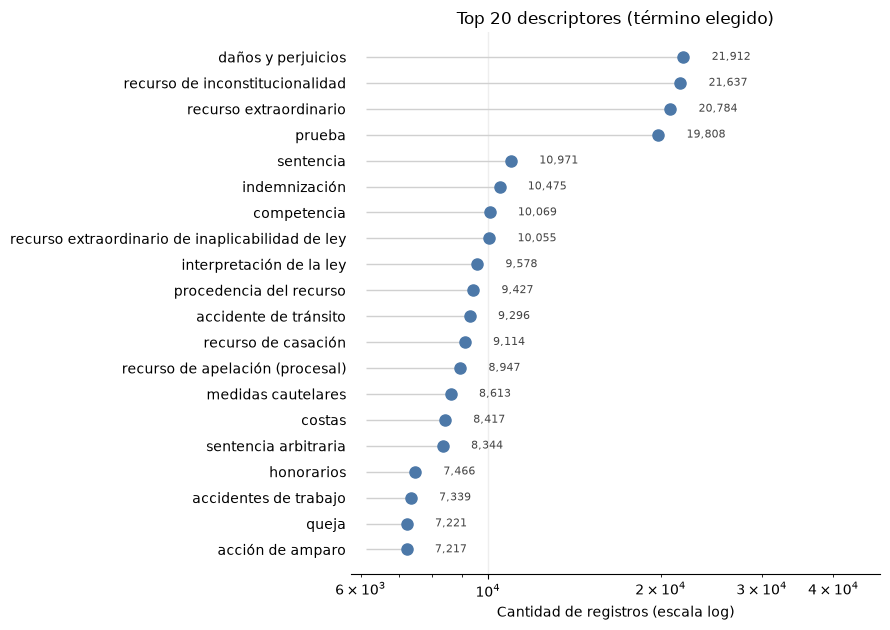

In [17]:
# Reutilizamos las listas ya desanidadas en la celda anterior; explode() deja una fila por término
terminos_elegidos = elegidos_por_registro.explode().dropna()

resumen_descriptores = resumen_desbalance(terminos_elegidos, "descriptores — término elegido")

mostrar_cabeza_y_cola(resumen_descriptores)

graficar_top(resumen_descriptores["n"], "Top 20 descriptores (término elegido)")

--- descriptores — rama del tesauro ---
Etiquetas totales: 986,764
Clases distintas:  3,787
Clase mayoritaria: Derecho procesal (295,932 | 29.99%)
Ratio mayoritaria/minoritaria: 295,932x
Clases con menos de 50 ejemplos: 3,561 (94.0% de las clases)
Cobertura del top-10: 86.38%
Cobertura del top-25: 94.41%


,n,pct,pct_acum
descriptores,,,
Derecho procesal,295932,29.99,29.99
Derecho civil,177298,17.97,47.96
Derecho constitucional,84026,8.52,56.47
Derecho penal,82969,8.41,64.88
Derecho laboral,59378,6.02,70.90
Derecho administrativo,54132,5.49,76.38
Derecho comercial,41540,4.21,80.59
Obligaciones y contratos,26161,2.65,83.25
Seguridad social,17426,1.77,85.01


... 3,737 clases intermedias sin mostrar (de 3,787 en total) ...


,n,pct,pct_acum
descriptores,,,
LEY DE FIRMA DIGITAL,1,0.0,100.0
Convención Marco de las Naciones Unidas sobre el Cambio Climático,1,0.0,100.0
Declaración de Principios Éticos en relación con el Cambio Climático,1,0.0,100.0
CONVENIO DE MONTREAL DE 1999 SOBRE UNIFICACIÓN DE CIERTAS REGLAS PARA EL TRANSPORTE AÉREO INTERNACIONAL,1,0.0,100.0
CÓDIGO DE TRÁNSITO Y TRANSPORTE DE LA CIUDAD DE BUENOS AIRES,1,0.0,100.0
COMISIÓN NACIONAL DE REGULACIÓN DEL TRANSPORTE,1,0.0,100.0
"Convención Interamericana contra la fabricación y el tráfico ilícitos de armas de fuego, municiones, explosivos y otros materiales relacionados",1,0.0,100.0
Tratado sobre el Comercio de Armas,1,0.0,100.0
CÁMARA NACIONAL DE APELACIONES EN LO CIVIL,1,0.0,100.0


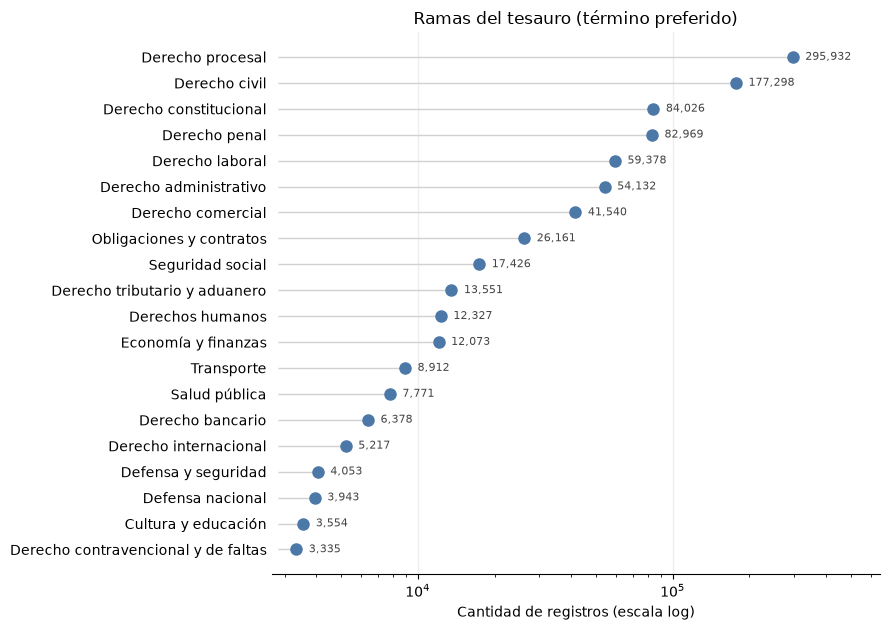

In [18]:
# Rama del tesauro: el primer tramo de "Derecho laboral/contrato de trabajo/.../despido".
# Es la misma información agrupada a un nivel más grueso, con muchas menos clases.
ramas_tesauro = (
    descriptores_validos.map(lambda v: sorted({t.split("/")[0].strip() for t in extraer_terminos(v, "preferido")}))
    .explode()
    .dropna()
)

resumen_ramas = resumen_desbalance(ramas_tesauro, "descriptores — rama del tesauro")

mostrar_cabeza_y_cola(resumen_ramas)

graficar_top(resumen_ramas["n"], "Ramas del tesauro (término preferido)")

###### 5.3 `tipo-tribunal`

Códigos cortos (`CS` = Corte Suprema, `CC` = Civil y Comercial, `LB` = Laboral, ...). El campo debería
ser un catálogo cerrado, pero trae ruido de carga: códigos repetidos en la misma celda (`CS CS`),
espacios de más, variantes de mayúsculas y —lo menos evidente— **la misma combinación tipeada en
distinto orden**: `CS CC` (504 registros) y `CC CS` (110) son el mismo par de fueros contado dos
veces. Una combinación es un conjunto, no una secuencia, así que ordenamos los códigos antes de
contar. Hay 8 pares en esa situación.

Valores distintos sin normalizar: 644
--- tipo-tribunal ---
Etiquetas totales: 767,118
Clases distintas:  507
Clase mayoritaria: CS (303,111 | 39.51%)
Ratio mayoritaria/minoritaria: 303,111x
Clases con menos de 50 ejemplos: 406 (80.1% de las clases)
Cobertura del top-10: 89.35%
Cobertura del top-25: 97.12%


,n,pct,pct_acum
tipo-tribunal,,,
CS,303111,39.51,39.51
CC,105110,13.70,53.21
LB,56297,7.34,60.55
PN,53352,6.95,67.51
CO,44142,5.75,73.26
CI,37636,4.91,78.17
NP,25732,3.35,81.52
LM,24667,3.22,84.74
CA,23840,3.11,87.85


... 457 clases intermedias sin mostrar (de 507 en total) ...


,n,pct,pct_acum
tipo-tribunal,,,
LD,1,0.0,100.0
LM PC,1,0.0,100.0
Q6,1,0.0,100.0
LK,1,0.0,100.0
NG,1,0.0,100.0
EU,1,0.0,100.0
JM KK,1,0.0,100.0
OO,1,0.0,100.0
BV UN,1,0.0,100.0


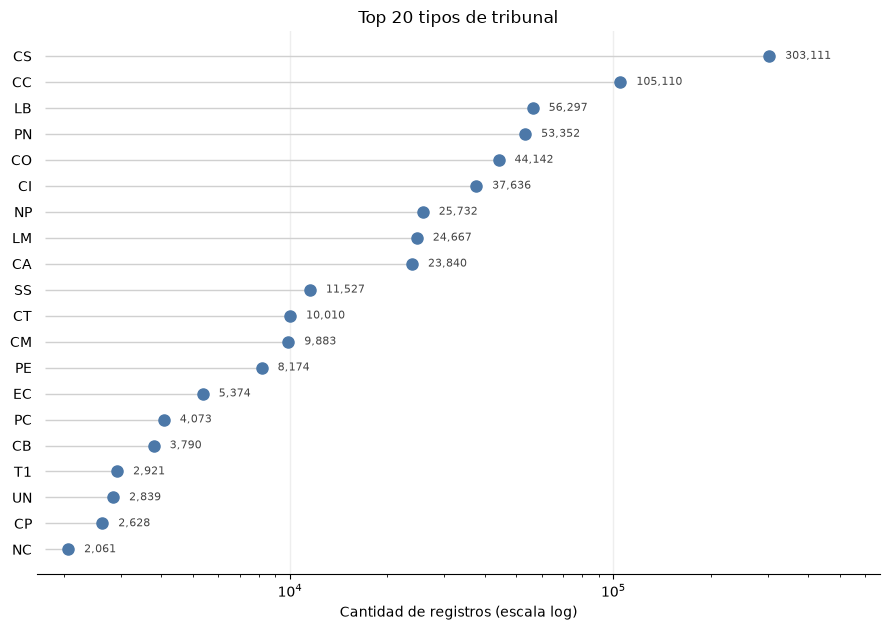

In [19]:
def normalizar_tipo_tribunal(valor):
    """Deduplica los códigos de la celda y los deja en un orden fijo."""
    # sorted(set(...)) y no dict.fromkeys(): una combinación de fueros es un CONJUNTO, el
    # orden en que el analista los tipeó no significa nada. Sin ordenar, 'CS CC' (504) y
    # 'CC CS' (110) cuentan como dos clases distintas; hay 8 pares así en el dataset.
    # El set además resuelve el caso 'CS CS' -> 'CS'.
    return " ".join(sorted(set(valor.upper().split())))


tipo_tribunal_crudo = df_clases["tipo-tribunal"].dropna()

print(f"Valores distintos sin normalizar: {tipo_tribunal_crudo.nunique():,}")

tipo_tribunal = tipo_tribunal_crudo.map(normalizar_tipo_tribunal)

resumen_tribunal = resumen_desbalance(tipo_tribunal, "tipo-tribunal")

mostrar_cabeza_y_cola(resumen_tribunal)

graficar_top(resumen_tribunal["n"], "Top 20 tipos de tribunal")

###### 5.4 `jurisdiccion`

Viene como diccionario: `{"codigo": "NACIONAL", "descripcion": "Nacional", "capital": "Nacional", "id-pais": 11}`.
Usamos `descripcion`, pero **normalizando a mayúsculas**: el dataset trae `Local` (433.342 registros) y
`LOCAL` (55) como valores distintos, y lo mismo con `Federal`/`FEDERAL`, `Nacional`/`NACIONAL` e
`Internacional`/`INTERNACIONAL`. Sin normalizar son 9 clases donde hay 5, y el ratio
mayoritaria/minoritaria da 216.671x en vez de 17.336x — porque la clase minoritaria pasa a ser
`INTERNACIONAL` con 2 registros, que no es una jurisdicción rara sino un error de tipeo.

Es la variable de menor cardinalidad de las cuatro, así que la mostramos completa y en escala lineal:
acá el gráfico sí puede mostrar la proporción real sin aplastar nada.

--- jurisdiccion ---
Etiquetas totales: 769,517
Clases distintas:  5
Clase mayoritaria: LOCAL (433,397 | 56.32%)
Ratio mayoritaria/minoritaria: 17,336x
Clases con menos de 50 ejemplos: 1 (20.0% de las clases)
Cobertura del top-5: 100.0%


,n,pct,pct_acum
jurisdiccion,,,
LOCAL,433397,56.32,56.32
FEDERAL,170369,22.14,78.46
NACIONAL,163293,21.22,99.68
INTERNACIONAL,2433,0.32,100.00
EXTRANJERA,25,0.00,100.00


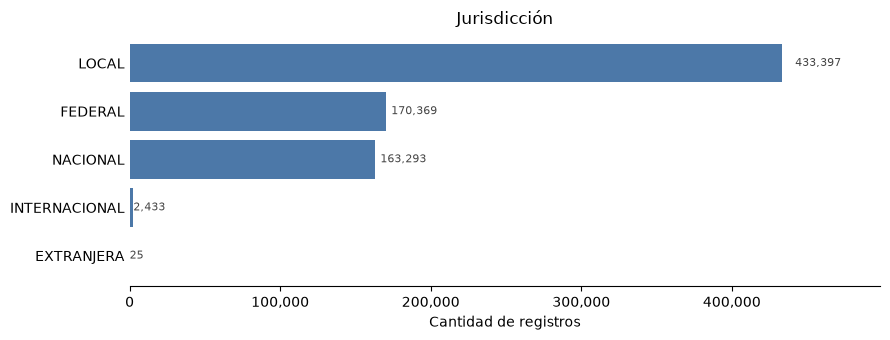

In [20]:
def extraer_jurisdiccion(valor):
    """Devuelve la descripción legible de la jurisdicción, ya normalizada."""
    if isinstance(valor, dict):
        # Si faltara 'descripcion' caemos a 'codigo', que es el mismo dato en formato crudo
        texto = valor.get("descripcion") or valor.get("codigo")
    else:
        # Algunos registros podrían traer el string directo en vez del dict
        texto = valor if isinstance(valor, str) else None

    if not isinstance(texto, str) or not texto.strip():
        return None

    # Mismo criterio que en materia y tipo-tribunal, y por la misma razón: el dataset trae
    # 'Local' (433.342) y 'LOCAL' (55) como si fueran jurisdicciones distintas. Sin esta
    # línea son 9 clases en lugar de 5, y el ratio mayoritaria/minoritaria da 216.671x
    # —porque la minoritaria pasa a ser 'INTERNACIONAL' con 2 casos— contra los 17.336x reales.
    return re.sub(r"\s+", " ", texto.strip()).upper()


jurisdiccion = df_clases["jurisdiccion"].map(extraer_jurisdiccion).dropna()

resumen_jurisdiccion = resumen_desbalance(jurisdiccion, "jurisdiccion", top=5)

display(resumen_jurisdiccion)

# Escala lineal y orden descendente: con pocas clases la comparación de magnitudes es directa
datos = resumen_jurisdiccion["n"].sort_values()
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.barh(datos.index, datos.values, color=COLOR_DATO)
ax.set_xlabel("Cantidad de registros")
ax.set_title("Jurisdicción")
# Separador de miles también en el eje, para leerlo igual que las etiquetas directas
ax.xaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
for y, valor in enumerate(datos.values):
    ax.text(valor * 1.02, y, f"{valor:,}", va="center", fontsize=8, color="#444444")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_xlim(right=datos.max() * 1.15)
plt.tight_layout()
plt.show()

###### 5.5 Comparación entre las cuatro variables

Puestas una al lado de la otra se ve el compromiso: cuanto más fina la etiqueta, más informativa para
el usuario final y más desbalanceada para el modelo.

In [21]:
candidatas = {
    "materia (cruda)": resumen_materia_cruda,
    "materia (normalizada)": resumen_materia,
    "descriptores (término)": resumen_descriptores,
    "descriptores (rama tesauro)": resumen_ramas,
    "tipo-tribunal": resumen_tribunal,
    "jurisdiccion": resumen_jurisdiccion,
}


def clases_para_cobertura(resumen, umbral=90):
    """Cuántas clases hacen falta para cubrir `umbral`% de las etiquetas."""
    # Contamos las que quedan por debajo del umbral y sumamos 1: esa es la que lo cruza.
    # min() evita devolver len+1 cuando ninguna clase llega al umbral (colas muy largas).
    return min(int((resumen["pct_acum"] < umbral).sum() + 1), len(resumen))


comparacion = pd.DataFrame(
    [
        {
            "variable": nombre,
            "clases": len(r),
            # En las variables multietiqueta este total supera la cantidad de registros:
            # cada registro aporta varias etiquetas.
            "etiquetas_totales": int(r["n"].sum()),
            "pct_clase_mayoritaria": r["pct"].iloc[0],
            "ratio_max_min": round(r["n"].max() / r["n"].min()),
            "clases_con_menos_de_50": int((r["n"] < MIN_EJEMPLOS_CLASE).sum()),
            "clases_para_90pct": clases_para_cobertura(r),
        }
        for nombre, r in candidatas.items()
    ]
)

display(comparacion)

,variable,clases,etiquetas_totales,pct_clase_mayoritaria,ratio_max_min,clases_con_menos_de_50,clases_para_90pct
0,materia (cruda),2636,483305,13.42,64845,2417,41
1,materia (normalizada),156,672225,21.91,147269,120,7
2,descriptores (término),20190,1737483,1.26,21912,15941,4103
3,descriptores (rama tesauro),3787,986764,29.99,295932,3561,14
4,tipo-tribunal,507,767118,39.51,303111,406,11
5,jurisdiccion,5,769517,56.32,17336,1,3
